In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [17]:
data = load_iris()
X,Y = data.data, data.target

In [18]:
X,Y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

One important point is that if we train the model on the entire dataset we can overfit it, where the model just memorizes the data,
Instead of generalizing it. To solve this, we do train test split


([<matplotlib.axis.XTick at 0x1eaeaa7efd0>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

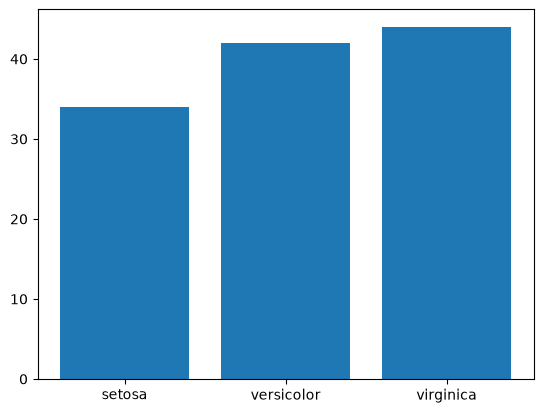

In [20]:
X_train, X_testing, Y_train, Y_testing = train_test_split(X, Y, test_size= 0.2)
#The distribution of testing and training data is random, which is not optimal
#We can visualize this using numpy,matplotlib
import numpy as np
import matplotlib.pyplot as plt

#counts the number of occurrences of each non-negative integer value in a 1D NumPy array
counts = np.bincount(Y_train)
position = np.arange(3)

plt.bar(position, counts)
plt.xticks(position, data.target_names)
        

([<matplotlib.axis.XTick at 0x1eaeabab750>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

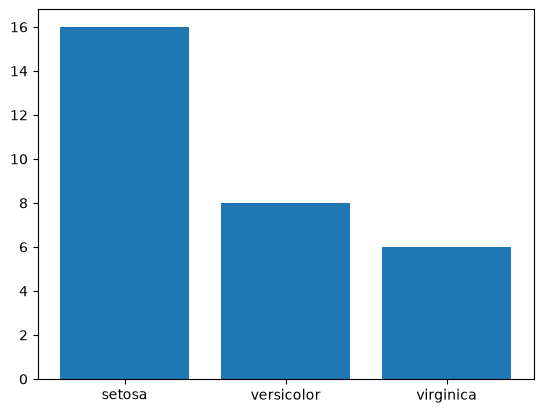

In [22]:
#Data was skewed in favour of one attribut. lets see if this is also true for test data:

counts = np.bincount(Y_testing)
position = np.arange(3)

plt.bar(position, counts)
plt.xticks(position, data.target_names)

To solve this issue of random distribution we use:
## StratifiedShuffleSplit:    
    class sklearn.model_selection.StratifiedShuffleSplit(n_splits=10, *, test_size=None, train_size=None, random_state=None)
    This cross-validation object is a merge of StratifiedKFold and ShuffleSplit, which returns stratified randomized folds. The folds are made by preserving the percentage of samples for each class in y in a binary or multiclass classification setting.

    StratifiedShuffleSplit class in scikit-learn is a cross-validator that merges ShuffleSplit and StratifiedKFold to return stratified, randomized folds. It shuffles the dataset and splits it into training and test sets while preserving the original percentage of samples for each class in the target variable (y)

In [23]:
from sklearn.model_selection import StratifiedShuffleSplit

Training split


([<matplotlib.axis.XTick at 0x1eaedbcbed0>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

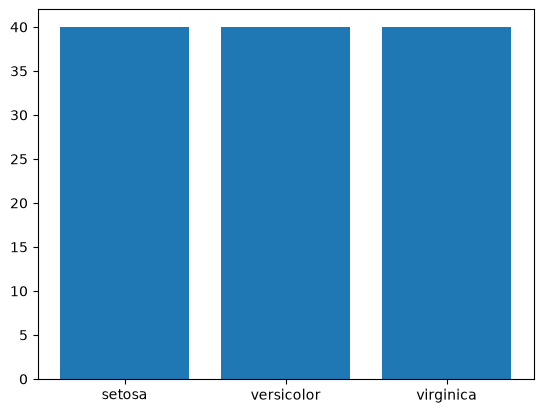

In [34]:
split = StratifiedShuffleSplit(n_splits= 3, test_size= 0.2)

for train_idx, test_idx in split.split(X,Y):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx],Y[test_idx]

print("Training split")
counts = np.bincount(Y_train)
position = np.arange(3)

plt.bar(position, counts)
plt.xticks(position, data.target_names)


/nTestSplit/n


([<matplotlib.axis.XTick at 0x1eaee202350>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

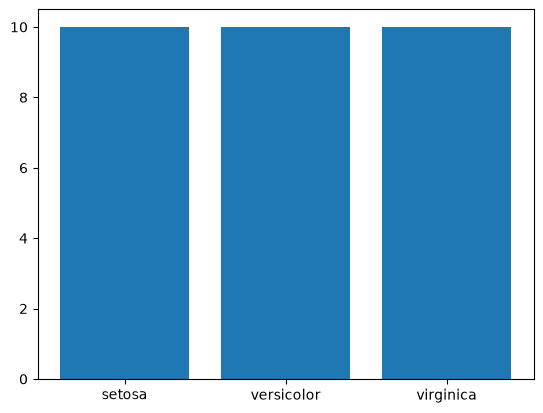

In [36]:
print("/nTestSplit/n")
counts = np.bincount(Y_test)
position = np.arange(3)

plt.bar(position, counts)
plt.xticks(position, data.target_names)